### Imports and load data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

df = pd.read_csv("../data/aqi_features.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"\nColumns:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")

Shape: (52, 19)
Date range: 2026-08-08 17:22:18 to 2026-08-11 08:05:06

Columns:
timestamp         datetime64[ns]
aqi                        int64
pm2_5                    float64
pm10                     float64
o3                       float64
no2                      float64
co                       float64
so2                      float64
temperature              float64
pressure                   int64
humidity                   int64
wind_speed               float64
wind_direction             int64
hour                       int64
day                        int64
day_of_week                int64
month                      int64
is_weekend                 int64
hour_category              int64
dtype: object

Null values:
timestamp         0
aqi               0
pm2_5             0
pm10              0
o3                0
no2               0
co                0
so2               0
temperature       0
pressure          0
humidity          0
wind_speed        0
wind_direction    0
hour

In [26]:
print(df.tail())

             timestamp  aqi  pm2_5   pm10     o3   no2     co   so2  \
47 2026-08-10 23:26:52   71  17.39  75.48  38.11  0.10  71.69  0.42   
48 2026-08-11 04:59:44   74  19.14  86.19  40.17  0.08  71.99  0.45   
49 2026-08-11 05:54:12   75  19.63  89.17  40.10  0.07  71.51  0.47   
50 2026-08-11 06:50:35   75  19.89  90.85  40.14  0.06  71.30  0.47   
51 2026-08-11 08:05:06   76  19.93  91.49  40.33  0.05  71.22  0.46   

    temperature  pressure  humidity  wind_speed  wind_direction  hour  day  \
47        26.78      1000        82        7.91             263    23   10   
48        28.34      1002        76        8.69             264     4   11   
49        28.54      1002        76        8.77             263     5   11   
50        29.01      1002        74        8.09             255     6   11   
51        29.25      1001        73        8.24             249     8   11   

    day_of_week  month  is_weekend  hour_category  
47            0      8           0              0  


In [15]:
print("\nAQI Statistics")
print(df["aqi"].describe())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDuplicate timestamps:", df["timestamp"].duplicated().sum())

print("\nUnique AQI values:")
print(df["aqi"].value_counts().sort_index())

print("\nTime gaps between observations:")
print(df["timestamp"].diff().describe())


AQI Statistics
count    52.000000
mean     73.269231
std       2.957976
min      68.000000
25%      71.000000
50%      74.000000
75%      75.250000
max      77.000000
Name: aqi, dtype: float64

Duplicate rows: 0

Duplicate timestamps: 0

Unique AQI values:
aqi
68     4
69     3
70     4
71     6
72     4
73     4
74     4
75    10
76     2
77    11
Name: count, dtype: int64

Time gaps between observations:
count                           51
mean     0 days 01:13:46.823529411
std      0 days 00:50:06.284675182
min                0 days 00:04:57
25%                0 days 00:55:49
50%                0 days 00:59:37
75%                0 days 01:37:49
max                0 days 05:32:52
Name: timestamp, dtype: object


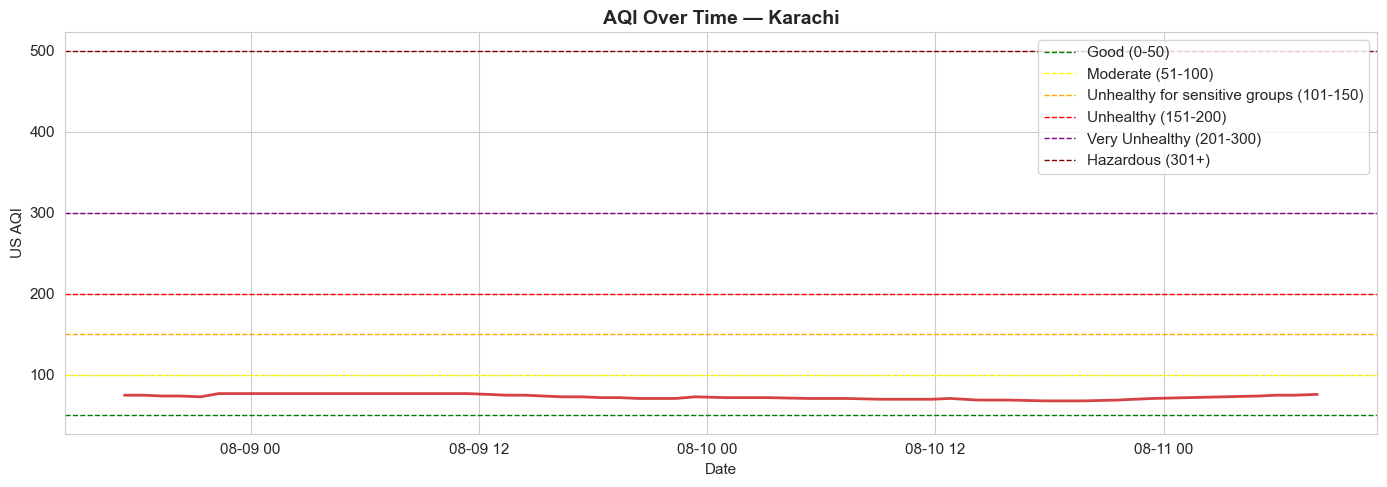

Days above 150 (Unhealthy): 0
Days above 200 (Very Unhealthy): 0


In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["timestamp"], df["aqi"], color="#cd1313", linewidth=2, alpha=0.8)

ax.axhline(50,  color="green", linestyle="--", linewidth=1, label="Good (0-50)")
ax.axhline(100, color="yellow", linestyle="--", linewidth=1, label="Moderate (51-100)")
ax.axhline(150, color="orange", linestyle="--", linewidth=1, label="Unhealthy for sensitive groups (101-150)")
ax.axhline(200, color="red", linestyle="--", linewidth=1, label="Unhealthy (151-200)")
ax.axhline(300, color="purple", linestyle="--", linewidth=1, label="Very Unhealthy (201-300)")
ax.axhline(500, color="maroon", linestyle="--", linewidth=1, label="Hazardous (301+)")

ax.set_title("AQI Over Time — Karachi", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("US AQI")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_over_time.png", dpi=150)
plt.show()
print(f"Days above 150 (Unhealthy): {(df['aqi'] > 150).sum()}")
print(f"Days above 200 (Very Unhealthy): {(df['aqi'] > 200).sum()}")

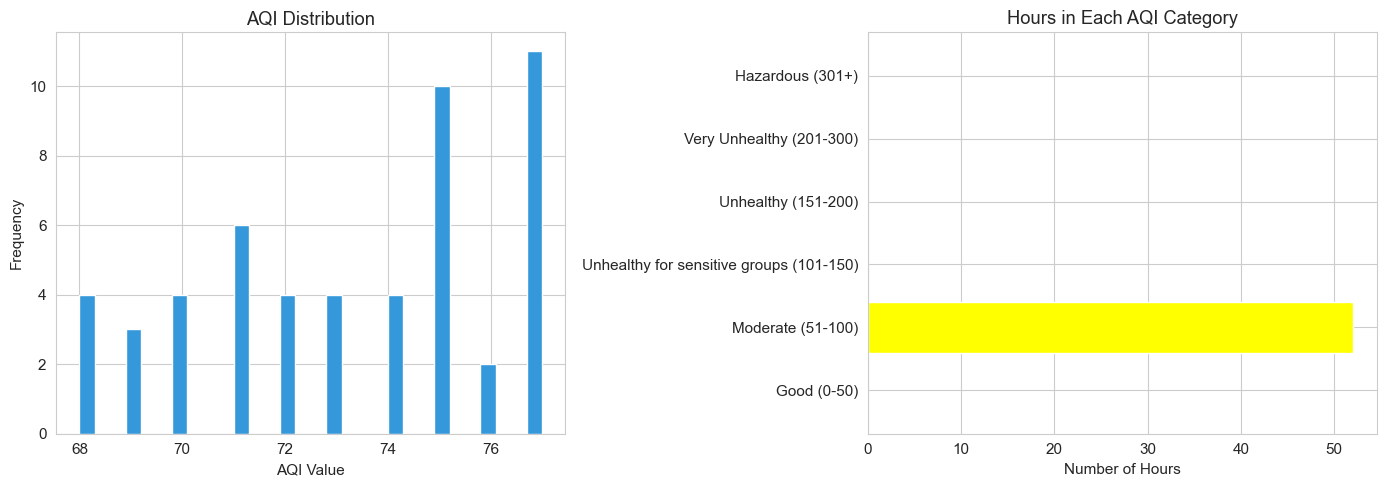

Good (0-50): 0 hours (0.0%)
Moderate (51-100): 52 hours (100.0%)
Unhealthy for sensitive groups (101-150): 0 hours (0.0%)
Unhealthy (151-200): 0 hours (0.0%)
Very Unhealthy (201-300): 0 hours (0.0%)
Hazardous (301+): 0 hours (0.0%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["aqi"], bins=30, color="#3498db", edgecolor="white")
axes[0].set_title("AQI Distribution")
axes[0].set_xlabel("AQI Value")
axes[0].set_ylabel("Frequency")

# AQI category breakdown
categories = {
    "Good (0-50)": (df["aqi"] <= 50).sum(),
    "Moderate (51-100)": ((df["aqi"] > 50) & (df["aqi"] <= 100)).sum(),
    "Unhealthy for sensitive groups (101-150)": ((df["aqi"] > 100) & (df["aqi"] <= 150)).sum(),
    "Unhealthy (151-200)": ((df["aqi"] > 150) & (df["aqi"] <= 200)).sum(),
    "Very Unhealthy (201-300)": ((df["aqi"] > 200) & (df["aqi"] <= 300)).sum(),
    "Hazardous (301+)": (df["aqi"] > 300).sum(),
}
colors = ["green","yellow","orange","red","purple","maroon"]
axes[1].barh(list(categories.keys()), list(categories.values()), color=colors)
axes[1].set_title("Hours in Each AQI Category")
axes[1].set_xlabel("Number of Hours")

plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_distribution.png", dpi=150)
plt.show()

for category, count in categories.items():
    percentage = count / len(df) * 100
    print(f"{category}: {count} hours ({percentage:.1f}%)")

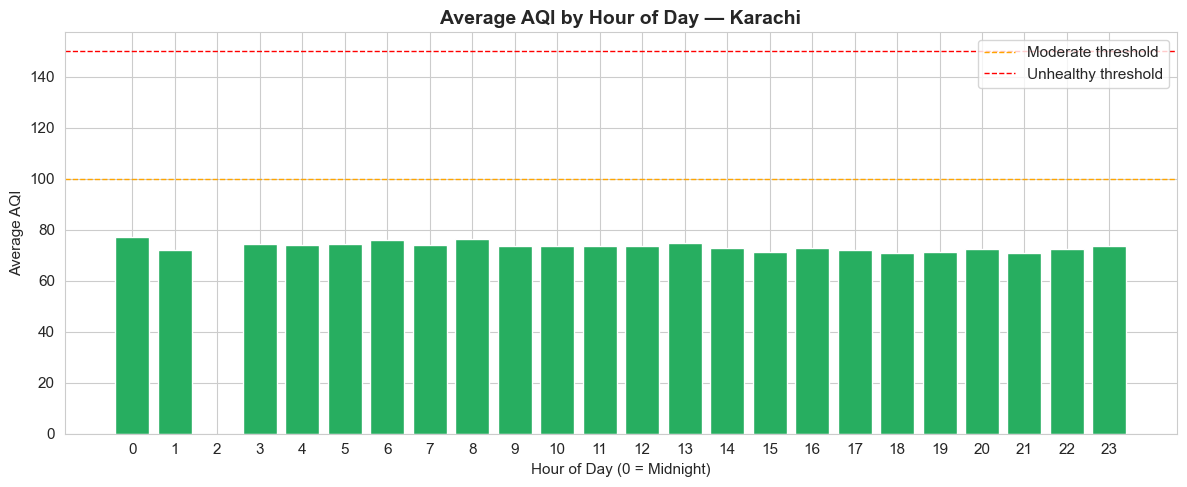

Peak AQI hour: 0:00 (avg 77.0)
Lowest AQI hour: 18:00 (avg 70.8)


In [19]:
hourly_avg = df.groupby("hour")["aqi"].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hourly_avg["hour"], hourly_avg["aqi"],
              color=["#e74c3c" if v > 150 else "#f39c12" if v > 100 
                     else "#27ae60" for v in hourly_avg["aqi"]])
ax.set_title("Average AQI by Hour of Day — Karachi", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour of Day (0 = Midnight)")
ax.set_ylabel("Average AQI")
ax.set_xticks(range(24))
ax.axhline(100, color="orange", linestyle="--", linewidth=1, label="Moderate threshold")
ax.axhline(150, color="red", linestyle="--", linewidth=1, label="Unhealthy threshold")
ax.legend()
plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_by_hour.png", dpi=150)
plt.show()

peak_hour = hourly_avg.loc[hourly_avg["aqi"].idxmax(), "hour"]
low_hour  = hourly_avg.loc[hourly_avg["aqi"].idxmin(), "hour"]
print(f"Peak AQI hour: {peak_hour}:00 (avg {hourly_avg['aqi'].max():.1f})")
print(f"Lowest AQI hour: {low_hour}:00 (avg {hourly_avg['aqi'].min():.1f})")

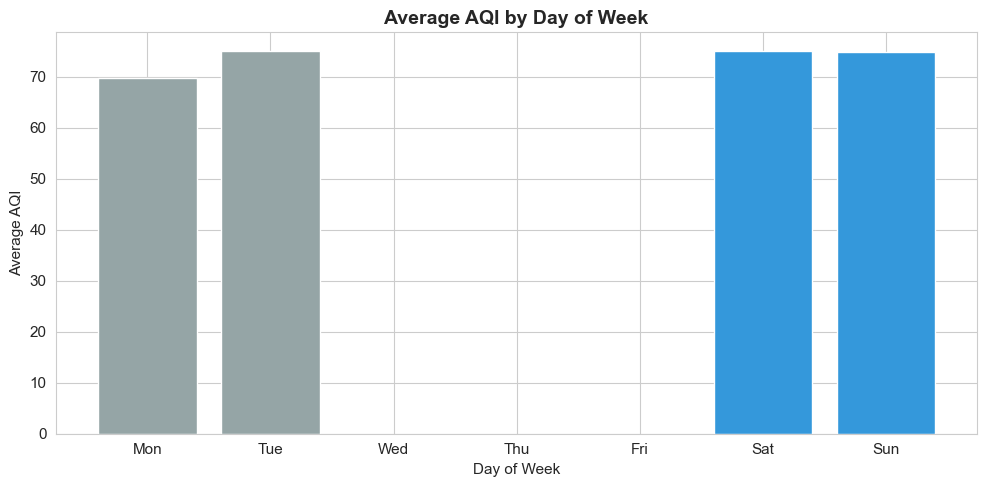

Weekday avg AQI: 72.41
Weekend avg AQI: 74.96


In [21]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

daily_avg = df.groupby("day_of_week")["aqi"].mean().reindex(range(7))

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    days,
    daily_avg.values, 
    color=["#95a5a6" if i < 5 else "#3498db" for i in range(7)]
)

ax.set_title("Average AQI by Day of Week", fontsize=14, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average AQI")

plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_by_day.png", dpi=150)
plt.show()

print("Weekday avg AQI:", daily_avg[:5].mean().round(2))
print("Weekend avg AQI:", daily_avg[5:].mean().round(2))

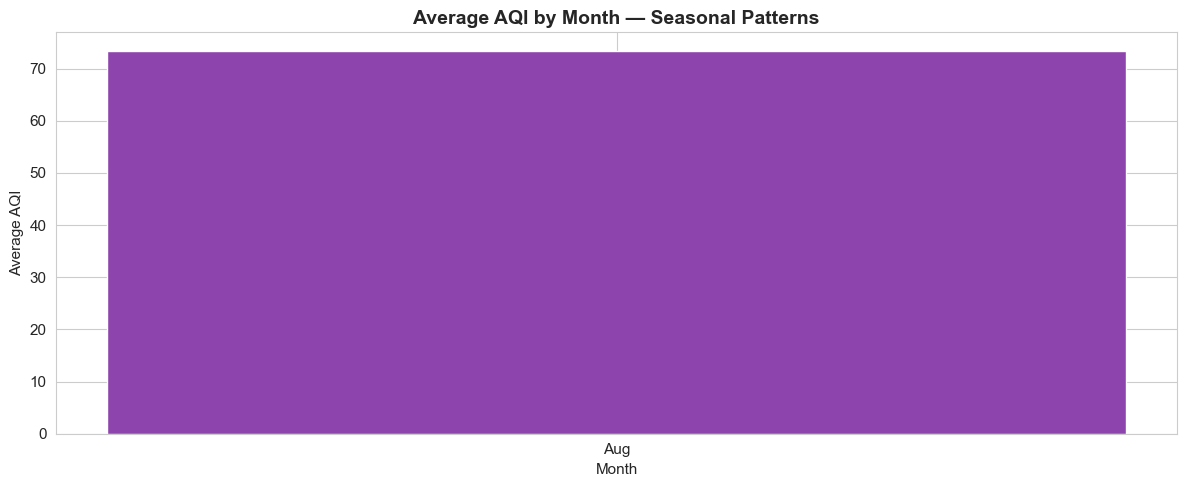

Average AQI by month:
month
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
6           NaN
7           NaN
8     73.269231
9           NaN
10          NaN
11          NaN
12          NaN
Name: aqi, dtype: float64


In [31]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_avg = df.groupby("month")["aqi"].mean().reindex(range(1, 13))

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(months[:len(monthly_avg)], monthly_avg.values, color="#8e44ad")

ax.set_title("Average AQI by Month — Seasonal Patterns", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")

plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_by_month.png", dpi=150)
plt.show()

print("Average AQI by month:")
print(monthly_avg)

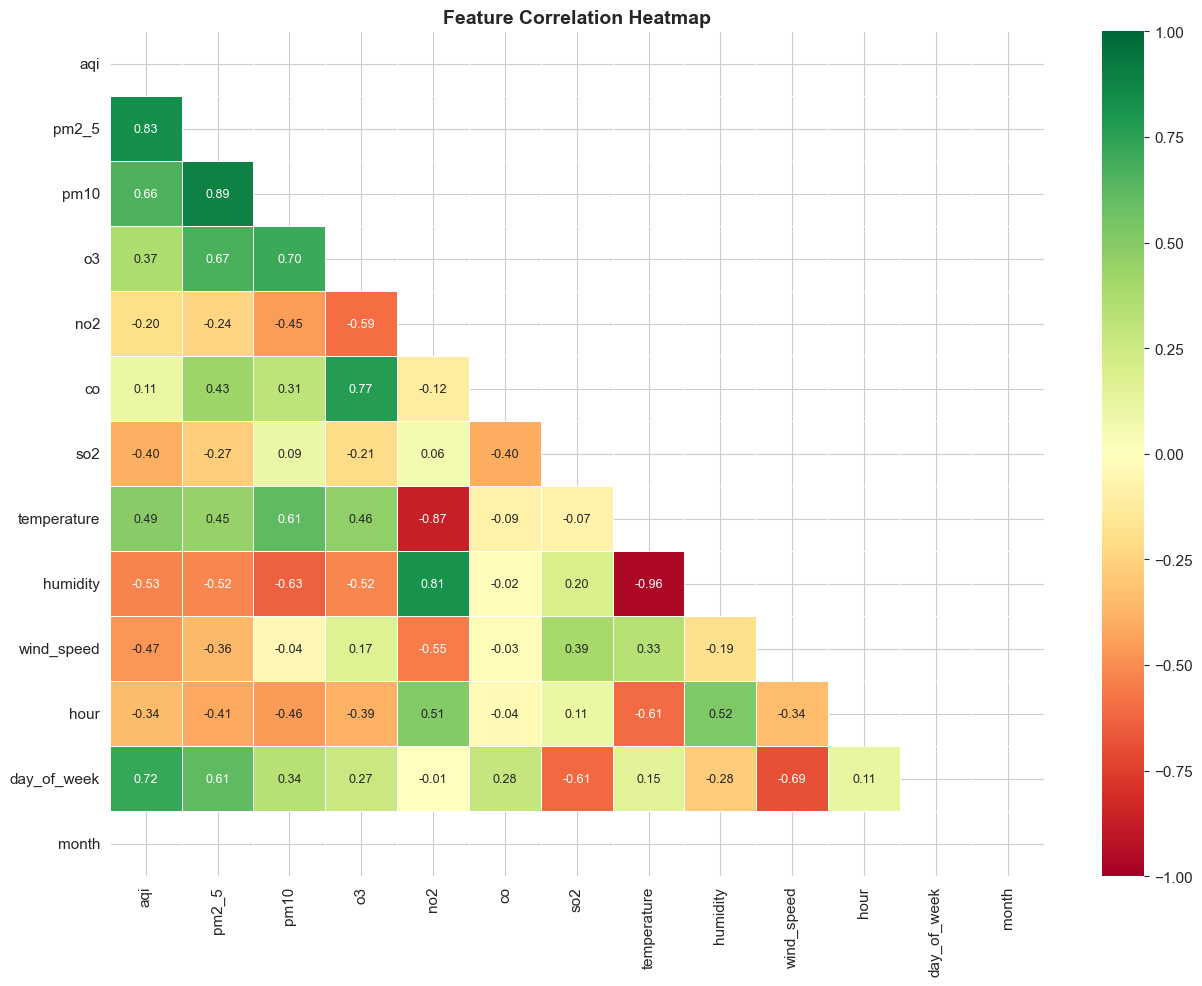

Top correlations with AQI:
pm2_5          0.833916
day_of_week    0.722205
pm10           0.659105
humidity       0.526766
temperature    0.488834
wind_speed     0.474742
so2            0.395515
o3             0.373388
Name: aqi, dtype: float64


In [32]:
feature_cols = ["aqi", "pm2_5", "pm10", "o3", "no2", "co", "so2", "temperature", "humidity", "wind_speed", "hour", "day_of_week", "month"]

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={"size": 9})

ax.set_title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../notebooks/plots/correlation_heatmap.png", dpi=150)
plt.show()

print("Top correlations with AQI:")
aqi_corr = corr["aqi"].drop("aqi").abs().sort_values(ascending=False)
print(aqi_corr.head(8))

            timestamp  aqi  aqi_change_rate
0 2026-08-08 17:22:18   75              NaN
1 2026-08-08 18:23:41   75              0.0
2 2026-08-08 19:23:00   74             -1.0
3 2026-08-08 20:19:27   74              0.0
4 2026-08-08 21:22:14   73             -1.0
5 2026-08-08 22:19:40   77              4.0
6 2026-08-08 23:19:56   77              0.0
7 2026-08-09 00:58:52   77              0.0
8 2026-08-09 03:02:06   77              0.0
9 2026-08-09 05:42:23   77              0.0


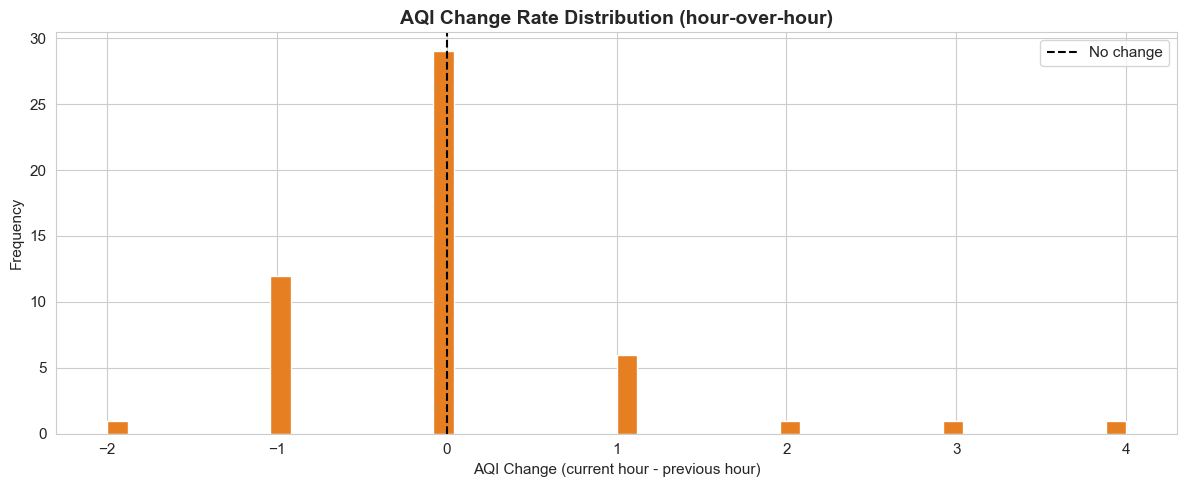

Mean change per hour: 0.02
Max increase in one hour: 4.00
Max decrease in one hour: -2.00


In [34]:
df = df.sort_values("timestamp").reset_index(drop=True)
df["aqi_change_rate"] = df["aqi"].diff()
print(df[["timestamp", "aqi", "aqi_change_rate"]].head(10))

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df["aqi_change_rate"].dropna(), bins=50,
        color="#e67e22", edgecolor="white")

ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="No change")

ax.set_title("AQI Change Rate Distribution (hour-over-hour)", fontsize=14, fontweight="bold")

ax.set_xlabel("AQI Change (current hour - previous hour)")
ax.set_ylabel("Frequency")
ax.legend()

plt.tight_layout()
plt.savefig("../notebooks/plots/aqi_change_rate.png", dpi=150)
plt.show()

print(f"Mean change per hour: {df['aqi_change_rate'].mean():.2f}")
print(f"Max increase in one hour: {df['aqi_change_rate'].max():.2f}")
print(f"Max decrease in one hour: {df['aqi_change_rate'].min():.2f}")